# 09 — Fully connected edge-attention simulator

A node-level simulator with **no graph latent bottleneck**. Every directed particle pair is an edge. One complete-edge attention pool builds a local token for each node; two standard Transformer layers then apply unrestricted self-attention across all node tokens. The noisy-LJ experiment uses the requested 200 trajectories × 200 frames: 100 networks for training, 20 for validation, and all remaining 80 for one final test.

In [1]:
%matplotlib inline
import os, sys
from copy import deepcopy
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src' / 'lss').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from lss.graph import clone_graph
from lss.latent.experiment import ground_truth_p_ratio, seed_everything
from lss.latent.simulation import complete_graph_edge_data, fit_edge_stats, pearson_r, r2_score
from lss.models.complete_graph_transformer_simulator import CompleteGraphTransformerSimulator
from lss.utils import resolve_device
DEVICE = resolve_device('auto')
DEVICE

/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

## Settings and deterministic split

The split is fixed before training. The model is trained only on the first 100 shuffled networks. Twenty validation networks choose checkpoints and the closed-loop curriculum; the final 80 networks remain untouched until the last cell.

In [2]:
SEED = 20260721
DATASET_KEY = 'lj_noisy'
TRAIN_NETWORKS, VAL_NETWORKS = 100, 20
TRANSITIONS_PER_NETWORK = 199
ROLLOUT_STEPS = [25, 49, 50, 75, 100, 125, 150, 199]
SELECT_ROLLOUT_NETWORKS = 10
ROLLOUT_STEP = max(ROLLOUT_STEPS)
TEST_NETWORKS = None       # None means every remaining held-out network
HIDDEN_SIZE = 64
TRANSFORMER_LAYERS, TRANSFORMER_HEADS = 2, 4
VAL_BATCHES = 100
DISTANCE_LOGIT_FLOOR = -8.0
WEIGHT_DECAY = 1e-5
TRAINING_STAGES = [
    # First two epochs are one-step warmup; the remaining epochs unroll four steps.
    {'name': 'warmup_to_4', 'epochs': 16, 'unroll': 4, 'warmup': 2, 'warmup_batches': 300, 'batches': 100, 'lr': 2e-4},
    {'name': 'unroll_8', 'epochs': 10, 'unroll': 8, 'warmup': 0, 'batches': 75, 'lr': 1e-4},
    {'name': 'unroll_16', 'epochs': 8, 'unroll': 16, 'warmup': 0, 'batches': 40, 'lr': 5e-5},
]
DATASETS = {
    'depablo_low_temp': PROJECT_ROOT / 'data' / 'depablo-near-zero-temp.pt',
    'reid': PROJECT_ROOT / 'data' / 'reid_200_frames.pt',
    'lj_noisy': PROJECT_ROOT / 'data' / 'lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt',
}
if DATASET_KEY not in DATASETS:
    raise ValueError(f'Unknown DATASET_KEY={DATASET_KEY!r}; choose from {sorted(DATASETS)}')
DATA = DATASETS[DATASET_KEY]
OUTPUT = PROJECT_ROOT / 'notebooks' / 'results' / '09_complete_graph_attention_simulator' / DATASET_KEY
OUTPUT.mkdir(parents=True, exist_ok=True)
assert DATA.exists(), DATA
seed_everything(SEED)
simulations = torch.load(DATA, map_location='cpu', weights_only=False)
order = np.random.default_rng(SEED).permutation(len(simulations))
train_ids = order[:TRAIN_NETWORKS]
val_ids = order[TRAIN_NETWORKS:TRAIN_NETWORKS + VAL_NETWORKS]
test_ids = order[TRAIN_NETWORKS + VAL_NETWORKS:]
train_sims = [simulations[i] for i in train_ids]
val_sims = [simulations[i] for i in val_ids]
test_sims = [simulations[i] for i in test_ids]
PRATIO_DATASET_NAME = 'lj_noisy' if DATASET_KEY.startswith('lj_noisy') else DATASET_KEY
PRATIO_CFG = {
    'temperature_pratio_estimator': 'robust', 'temperature_pratio_min_fit_frames': 8,
    'temperature_pratio_min_driven_strain_range': 1e-3, 'temperature_pratio_smooth_window': 5,
}
print({'dataset': DATASET_KEY, 'total': len(simulations), 'train': len(train_sims), 'val': len(val_sims), 'test': len(test_sims),
       'nodes': train_sims[0][0].x.size(0), 'frames': len(train_sims[0])})

{'dataset': 'lj_noisy', 'total': 200, 'train': 100, 'val': 20, 'test': 80, 'nodes': 125, 'frames': 200}


## Complete-graph inputs and training statistics

Node inputs contain current normalized position, current displacement from the static reference, normalized reference position, and next-step progress. Edge inputs are the 13 complete-pair geometry/property features used in 07/08. Attention has only a geometric distance prior—there is no bond-logit boost. The target is the **next position relative to the static reference**, not the tiny frame increment. This makes the reference geometry a restoring anchor without supplying an affine solution.

In [3]:
def transition_rows(sims):
    return [(sim_index, t) for sim_index, sim in enumerate(sims)
            for t in range(min(TRANSITIONS_PER_NETWORK, len(sim) - 1))]

train_rows = transition_rows(train_sims)
val_rows = transition_rows(val_sims)

def reference_geometry(sim, device):
    ref = sim[0].x[:, :2].to(device).float()
    low, high = ref.min(0).values, ref.max(0).values
    scale = (high - low).clamp_min(1e-6)
    normalized = 2 * (ref - (low + high) / 2) / scale
    return ref, normalized, scale

def target_next_state_stats(sims, rows):
    chunks = []
    for sim_index, t in rows:
        sim = sims[sim_index]
        ref, _, scale = reference_geometry(sim, 'cpu')
        next_state = (sim[t + 1].x[:, :2].float() - ref) / scale
        chunks.append(next_state)
    values = torch.cat(chunks)
    return values.mean(0, keepdim=True), values.std(0, keepdim=True).clamp_min(1e-7)

target_mean, target_std = target_next_state_stats(train_sims, train_rows)
bond_lengths = torch.cat([
    torch.linalg.vector_norm(sim[0].edge_attr[:, :2].float(), dim=1)
    for sim in train_sims
])
ATTENTION_LENGTH_SCALE = float(bond_lengths.median().clamp_min(1e-6))
edge_stat_indices = np.linspace(0, len(train_rows) - 1, min(80, len(train_rows)), dtype=int)
edge_stat_rows = [train_rows[int(index)] for index in edge_stat_indices]
edge_mean, edge_std = fit_edge_stats(
    train_sims, edge_stat_rows, pos_dim=2, batch_graphs=1, device=DEVICE, edge_mode='complete'
)
target_mean, target_std = target_mean.to(DEVICE), target_std.to(DEVICE)
edge_mean, edge_std = edge_mean.to(DEVICE), edge_std.to(DEVICE)
print({'train_transitions': len(train_rows), 'val_transitions': len(val_rows),
       'target_mean': target_mean.cpu().numpy(), 'target_std': target_std.cpu().numpy(),
       'edge_features': edge_mean.numel(),
       'attention_length_scale': ATTENTION_LENGTH_SCALE})

{'train_transitions': 19900, 'val_transitions': 3980, 'target_mean': array([[2.680204e-06, 9.622810e-06]], dtype=float32), 'target_std': array([[0.0054933 , 0.00287098]], dtype=float32), 'edge_features': 13, 'attention_length_scale': 1.1966742277145386}


In [4]:
def geometric_attention_bias(raw_edge_features):
    # complete_graph_edge_data layout: current length is column 5.
    current_distance = raw_edge_features[:, 5]
    distance_bias = -0.5 * (current_distance / ATTENTION_LENGTH_SCALE).square()
    distance_bias = distance_bias.clamp_min(DISTANCE_LOGIT_FLOOR)
    return distance_bias

def make_inputs(sim, t, current_graph, with_target=True):
    ref, ref_normalized, scale = reference_geometry(sim, DEVICE)
    current_pos = current_graph.x[:, :2].to(DEVICE).float()
    ref_center = 0.5 * (ref.min(0).values + ref.max(0).values)
    current_normalized = 2 * (current_pos - ref_center) / scale
    current_delta = (current_pos - ref) / scale
    progress = torch.full((ref.size(0), 1), (t + 1) / (len(sim) - 1), device=DEVICE)
    node = torch.cat([current_normalized, current_delta, ref_normalized, progress], dim=1)
    edge_index, raw_edge, _ = complete_graph_edge_data(
        sim[0], current_graph, pos_dim=2, device=DEVICE,
    )
    target = None
    if with_target:
        next_state = (sim[t + 1].x[:, :2].to(DEVICE).float() - ref) / scale
        target = (next_state - target_mean) / target_std
    return (node, (raw_edge - edge_mean) / edge_std, edge_index,
            geometric_attention_bias(raw_edge), target, ref, scale)

def predicted_graph(template_graph, position):
    graph = clone_graph(template_graph).to(position.device)
    graph.x = graph.x.clone().float()
    graph.x[:, :2] = position
    return graph

## Train the node simulator

After two teacher-forced warmup epochs, training is closed-loop: the model consumes its own predicted positions for 4, then 8, then 16 steps, and the position error is backpropagated through the unroll. This directly teaches recovery from off-manifold states. There is still no p-ratio loss, latent bottleneck, MI loss, observed trajectory history, force target, or affine answer. Full 199-step p-ratio on 10 validation networks selects each stage checkpoint; the test split is never inspected during training.

/home/alexz/Documents/course_project/src/lss/models/complete_graph_transformer_simulator.py:80: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


stage=warmup_to_4 epoch=01 train=0.45442 val_state_R2=0.7642 val_rollout_R2=nan
stage=warmup_to_4 epoch=02 train=0.31274 val_state_R2=0.8365 val_rollout_R2=-0.9712
stage=warmup_to_4 epoch=03 train=0.24098 val_state_R2=0.8427 val_rollout_R2=nan
stage=warmup_to_4 epoch=04 train=0.27436 val_state_R2=0.8474 val_rollout_R2=-1.3878
stage=warmup_to_4 epoch=05 train=0.25767 val_state_R2=0.8513 val_rollout_R2=nan
stage=warmup_to_4 epoch=06 train=0.28028 val_state_R2=0.8575 val_rollout_R2=-1.0650
stage=warmup_to_4 epoch=07 train=0.32774 val_state_R2=0.8526 val_rollout_R2=nan
stage=warmup_to_4 epoch=08 train=0.26472 val_state_R2=0.8584 val_rollout_R2=-6.7546
stage=warmup_to_4 epoch=09 train=0.18185 val_state_R2=0.8805 val_rollout_R2=nan
stage=warmup_to_4 epoch=10 train=0.18445 val_state_R2=0.8898 val_rollout_R2=-0.4207
stage=warmup_to_4 epoch=11 train=0.20005 val_state_R2=0.8645 val_rollout_R2=nan
stage=warmup_to_4 epoch=12 train=0.23122 val_state_R2=0.8960 val_rollout_R2=-1.1781
stage=warmup_to_

,epoch,stage,unroll_steps,train_loss,val_loss,train_next_state_r2,val_next_state_r2,val_rollout_pratio_r2
29,30,unroll_16,16,0.189605,0.148953,0.883727,0.892903,0.275781
30,31,unroll_16,16,0.310951,0.146977,0.882004,0.891535,NaN
31,32,unroll_16,16,0.206217,0.144705,0.887419,0.894939,0.371585
32,33,unroll_16,16,0.222325,0.145411,0.883832,0.894101,NaN
33,34,unroll_16,16,0.183698,0.150568,0.880268,0.888073,-0.008081


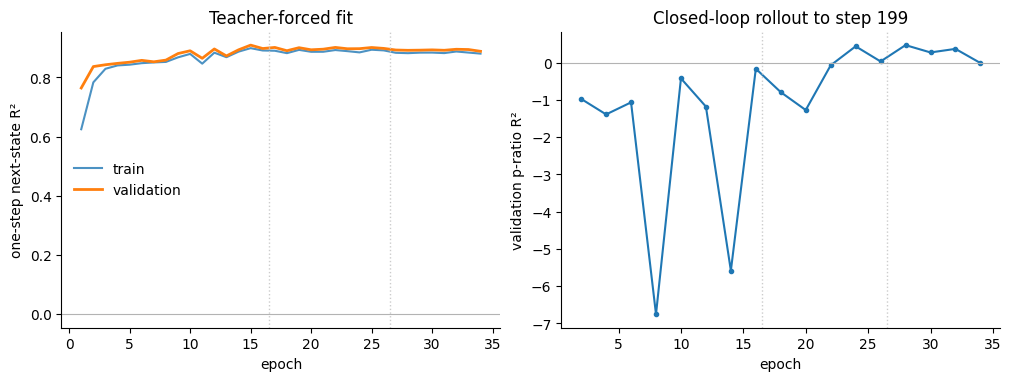

In [5]:
model = CompleteGraphTransformerSimulator(
    node_dim=7, edge_dim=13, hidden_size=HIDDEN_SIZE,
    transformer_layers=TRANSFORMER_LAYERS, transformer_heads=TRANSFORMER_HEADS,
    transformer_dropout=0.0, output_dim=2,
).to(DEVICE)

def decode_next_position(prediction, ref, scale):
    next_state = prediction * target_std + target_mean
    return ref + next_state * scale

def run_one_step_epoch(active_model, sims, rows, optimizer=None, max_batches=None, seed=0):
    training = optimizer is not None
    active_model.train(training)
    indices = np.arange(len(rows))
    if training:
        np.random.default_rng(seed).shuffle(indices)
    if max_batches is not None and len(indices) > int(max_batches):
        indices = (indices[:int(max_batches)] if training else
                   np.linspace(0, len(indices) - 1, int(max_batches), dtype=int))
    losses, predicted_parts, target_parts = [], [], []
    for index in indices:
        sim_index, t = rows[int(index)]
        inputs = make_inputs(sims[sim_index], t, sims[sim_index][t], with_target=True)
        node, edge, edge_index, attention_bias, target, _, _ = inputs
        prediction = active_model(node, edge, edge_index, attention_bias=attention_bias)
        loss = F.mse_loss(prediction, target)
        if training:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(active_model.parameters(), 1.0)
            optimizer.step()
        losses.append(float(loss.detach()))
        predicted_parts.append((prediction * target_std + target_mean).detach().cpu().reshape(-1))
        target_parts.append((target * target_std + target_mean).detach().cpu().reshape(-1))
    predicted_values = torch.cat(predicted_parts).numpy()
    target_values = torch.cat(target_parts).numpy()
    return {'loss': float(np.mean(losses)), 'next_state_r2': r2_score(target_values, predicted_values)}

def run_unroll_epoch(active_model, sims, optimizer, unroll_steps, max_batches, seed):
    active_model.train(True)
    chunks = [(sim_index, start) for sim_index, sim in enumerate(sims)
              for start in range(min(TRANSITIONS_PER_NETWORK, len(sim) - 1) - unroll_steps + 1)]
    np.random.default_rng(seed).shuffle(chunks)
    chunks = chunks[:int(max_batches)]
    losses = []
    for sim_index, start in chunks:
        sim = sims[sim_index]
        current = clone_graph(sim[start]).to(DEVICE)
        weighted_losses, weight_sum = [], 0.0
        for offset in range(unroll_steps):
            t = start + offset
            node, edge, edge_index, bias, target, ref, scale = make_inputs(
                sim, t, current, with_target=True,
            )
            prediction = active_model(node, edge, edge_index, attention_bias=bias)
            weight = 1.0 + offset / max(1, unroll_steps)
            weighted_losses.append(weight * F.mse_loss(prediction, target))
            weight_sum += weight
            current = predicted_graph(sim[t + 1], decode_next_position(prediction, ref, scale))
        loss = torch.stack(weighted_losses).sum() / weight_sum
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(active_model.parameters(), 1.0)
        optimizer.step()
        losses.append(float(loss.detach()))
    return float(np.mean(losses))

def rollout_with_model(active_model, sim, horizon):
    predicted = [clone_graph(sim[0]).cpu()]
    current = predicted[0]
    with torch.no_grad():
        for next_step in range(1, horizon + 1):
            node, edge, edge_index, bias, _, ref, scale = make_inputs(
                sim, next_step - 1, current, with_target=False,
            )
            prediction = active_model(node, edge, edge_index, attention_bias=bias)
            current = predicted_graph(
                sim[next_step], decode_next_position(prediction, ref, scale),
            ).cpu()
            predicted.append(current)
    return predicted

def validation_rollout_r2(active_model):
    true_ratios, predicted_ratios = [], []
    for sim in val_sims[:SELECT_ROLLOUT_NETWORKS]:
        predicted = rollout_with_model(active_model, sim, ROLLOUT_STEP)
        true_ratios.append(ground_truth_p_ratio(
            sim, last_index=ROLLOUT_STEP, dataset_name=PRATIO_DATASET_NAME, cfg=PRATIO_CFG,
        ))
        predicted_ratios.append(ground_truth_p_ratio(
            predicted, dataset_name=PRATIO_DATASET_NAME, cfg=PRATIO_CFG,
        ))
    return r2_score(true_ratios, predicted_ratios)

seed_everything(SEED)
history_rows, global_epoch = [], 0
for stage_index, stage in enumerate(TRAINING_STAGES):
    optimizer = torch.optim.AdamW(model.parameters(), lr=stage['lr'], weight_decay=WEIGHT_DECAY)
    stage_best_state, stage_best_r2 = None, float('-inf')
    for local_epoch in range(1, stage['epochs'] + 1):
        global_epoch += 1
        use_unroll = local_epoch > stage.get('warmup', 0)
        if use_unroll:
            train_loss = run_unroll_epoch(
                model, train_sims, optimizer, stage['unroll'], stage['batches'], SEED + global_epoch,
            )
            with torch.no_grad():
                train_metrics = run_one_step_epoch(model, train_sims, train_rows, None, VAL_BATCHES, SEED)
        else:
            train_metrics = run_one_step_epoch(
                model, train_sims, train_rows, optimizer, stage['warmup_batches'], SEED + global_epoch,
            )
            train_loss = train_metrics['loss']
        with torch.no_grad():
            val_metrics = run_one_step_epoch(model, val_sims, val_rows, None, VAL_BATCHES, SEED)
            selection_epoch = local_epoch % 2 == 0 or local_epoch == stage['epochs']
            val_rollout_r2 = validation_rollout_r2(model) if selection_epoch else np.nan
        history_rows.append({
            'epoch': global_epoch, 'stage': stage['name'], 'unroll_steps': stage['unroll'] if use_unroll else 1,
            'train_loss': train_loss, 'val_loss': val_metrics['loss'],
            'train_next_state_r2': train_metrics['next_state_r2'],
            'val_next_state_r2': val_metrics['next_state_r2'],
            'val_rollout_pratio_r2': val_rollout_r2,
        })
        if np.isfinite(val_rollout_r2) and val_rollout_r2 > stage_best_r2 + 1e-4:
            stage_best_r2 = val_rollout_r2
            stage_best_state = deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
        print(f"stage={stage['name']} epoch={local_epoch:02d} train={train_loss:.5g} "
              f"val_state_R2={val_metrics['next_state_r2']:.4f} "
              f"val_rollout_R2={val_rollout_r2:.4f}", flush=True)
    if stage_best_state is None:
        raise RuntimeError(f"No valid rollout checkpoint in stage {stage['name']}")
    model.load_state_dict(stage_best_state)

history = pd.DataFrame(history_rows)
model.eval()
display(history.tail())
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), constrained_layout=True)
axes[0].plot(history.epoch, history.train_next_state_r2, label='train', alpha=.8)
axes[0].plot(history.epoch, history.val_next_state_r2, label='validation', lw=2)
axes[0].set(xlabel='epoch', ylabel='one-step next-state R²', title='Teacher-forced fit')
axes[0].legend(frameon=False)
finite_history = history.dropna(subset=['val_rollout_pratio_r2'])
axes[1].plot(finite_history.epoch, finite_history.val_rollout_pratio_r2, marker='o', ms=3)
axes[1].set(xlabel='epoch', ylabel='validation p-ratio R²', title=f'Closed-loop rollout to step {ROLLOUT_STEP}')
for boundary in np.cumsum([stage['epochs'] for stage in TRAINING_STAGES])[:-1]:
    for ax in axes: ax.axvline(boundary + .5, color='.8', ls=':', lw=1)
for ax in axes:
    ax.axhline(0, color='.7', lw=.8)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()
fig.savefig(OUTPUT / 'closed_loop_training_history.png', dpi=250, bbox_inches='tight')

## Recursive rollout and p-ratio R² by horizon

Only the static frame initializes each test rollout. At every step, the model predicts the next deformation relative to that same static reference and rebuilds all complete-pair features from its own predicted positions. The target frame contributes only the prescribed periodic box schedule and graph container—not its positions. P-ratio is evaluated at several horizons, with all 80 test networks used exactly once.

In [6]:
def rollout_simulation(sim, horizon):
    if horizon >= len(sim):
        raise ValueError(f'horizon {horizon} requires at least {horizon + 1} frames')
    return rollout_with_model(model, sim, horizon)

def trajectory_p_ratio(path):
    return ground_truth_p_ratio(path, dataset_name=PRATIO_DATASET_NAME, cfg=PRATIO_CFG)
final_test_sims = test_sims if TEST_NETWORKS is None else test_sims[:TEST_NETWORKS]
rows = []
for test_index, sim in enumerate(final_test_sims):
    predicted_path = rollout_simulation(sim, ROLLOUT_STEP)
    for rollout_step in ROLLOUT_STEPS:
        true_path = sim[:rollout_step + 1]
        rows.append({
            'rollout_step': rollout_step, 'test_index': test_index,
            'source_sim_id': int(getattr(sim[0], 'source_sim_id', test_index)),
            'true_p_ratio': trajectory_p_ratio(true_path),
            'pred_p_ratio': trajectory_p_ratio(predicted_path[:rollout_step + 1]),
        })
    if test_index == 0 or (test_index + 1) % 5 == 0:
        print(f'rolled out {test_index + 1}/{len(final_test_sims)}', flush=True)
predictions = pd.DataFrame(rows).dropna()
if len(predictions) < 2:
    raise RuntimeError('Need at least two finite test rollouts for p-ratio R²')
metric_rows = []
for rollout_step, group in predictions.groupby('rollout_step', sort=True):
    metric_rows.append({
        'rollout_step': int(rollout_step), 'test_networks': len(group),
        'p_ratio_r2': r2_score(group['true_p_ratio'], group['pred_p_ratio']),
        'p_ratio_pearson': pearson_r(group['true_p_ratio'], group['pred_p_ratio']),
    })
rollout_metrics = pd.DataFrame(metric_rows)
predictions.to_csv(OUTPUT / 'test_pratio_predictions_by_horizon.csv', index=False)
rollout_metrics.to_csv(OUTPUT / 'test_pratio_r2_by_horizon.csv', index=False)
display(rollout_metrics.round(4))

rolled out 1/80
rolled out 5/80
rolled out 10/80
rolled out 15/80
rolled out 20/80
rolled out 25/80
rolled out 30/80
rolled out 35/80
rolled out 40/80
rolled out 45/80
rolled out 50/80
rolled out 55/80
rolled out 60/80
rolled out 65/80
rolled out 70/80
rolled out 75/80
rolled out 80/80


,rollout_step,test_networks,p_ratio_r2,p_ratio_pearson
0,25,80,-0.1102,0.5725
1,49,80,0.1187,0.6847
2,50,80,0.1248,0.6877
3,75,80,0.2976,0.6711
4,100,80,0.4709,0.7429
5,125,80,0.5691,0.7890
6,150,80,0.6211,0.8109
7,199,80,0.6885,0.8489


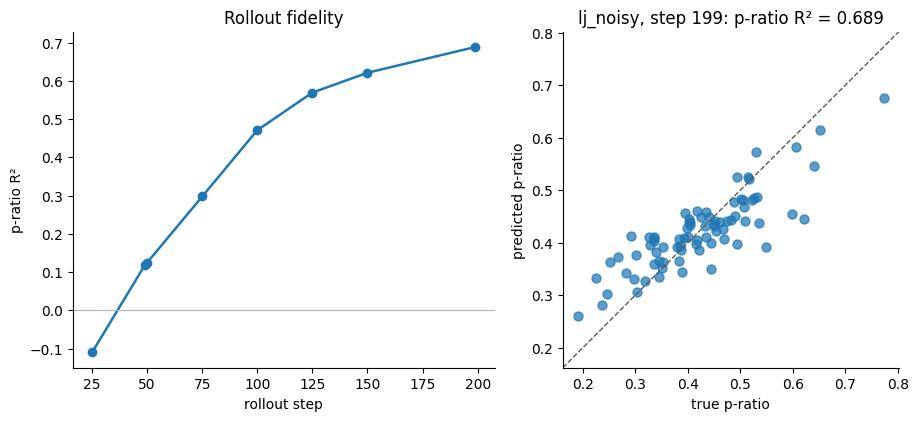

In [7]:
final_predictions = predictions[predictions['rollout_step'].eq(ROLLOUT_STEP)]
PRATIO_R2 = rollout_metrics.loc[rollout_metrics['rollout_step'].eq(ROLLOUT_STEP), 'p_ratio_r2'].iloc[0]
limits = [min(final_predictions['true_p_ratio'].min(), final_predictions['pred_p_ratio'].min()),
          max(final_predictions['true_p_ratio'].max(), final_predictions['pred_p_ratio'].max())]
padding = .05 * max(limits[1] - limits[0], 1e-6)
limits = [limits[0] - padding, limits[1] + padding]
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.1), constrained_layout=True)
axes[0].plot(rollout_metrics['rollout_step'], rollout_metrics['p_ratio_r2'], marker='o', lw=1.8)
axes[0].axhline(0, color='.7', lw=.8)
axes[0].set(xlabel='rollout step', ylabel='p-ratio R²', title='Rollout fidelity')
axes[1].scatter(final_predictions['true_p_ratio'], final_predictions['pred_p_ratio'], s=42, alpha=.72)
axes[1].plot(limits, limits, color='.35', ls='--', lw=1)
axes[1].set(xlim=limits, ylim=limits, xlabel='true p-ratio', ylabel='predicted p-ratio',
            title=f'{DATASET_KEY}, step {ROLLOUT_STEP}: p-ratio R² = {PRATIO_R2:.3f}')
axes[1].set_aspect('equal', adjustable='box')
for ax in axes: ax.spines[['top', 'right']].set_visible(False)
plt.show()
fig.savefig(OUTPUT / 'pratio_r2_by_rollout_step.png', dpi=250, bbox_inches='tight')